In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)   

In [2]:
n = 2000   
risk_zone = np.random.choice(
    ["High", "Medium", "Low"],
    size=n,
    p=[0.40, 0.35, 0.25]
)

medical_severity = []
for zone in risk_zone:
    if zone == "High":
        medical_severity.append(np.random.choice(
            ["Critical", "Serious", "Moderate", "Mild"],
            p=[0.35, 0.35, 0.20, 0.10]
        ))
    elif zone == "Medium":
        medical_severity.append(np.random.choice(
            ["Critical", "Serious", "Moderate", "Mild"],
            p=[0.15, 0.35, 0.35, 0.15]
        ))
    else:
        medical_severity.append(np.random.choice(
            ["Critical", "Serious", "Moderate", "Mild"],
            p=[0.05, 0.20, 0.40, 0.35]
        ))


age_category  = np.random.choice(["Baby", "Adult", "Elderly"], size=n, p=[0.15, 0.65, 0.20])
gender        = np.random.choice(["Male", "Female"],            size=n, p=[0.50, 0.50])
disaster_type = np.random.choice(["Flood", "Storm", "Earthquake", "Wildfire"], size=n)


vital_signs = np.where(np.array(medical_severity) == "Critical",  np.random.normal(25, 10, n),
              np.where(np.array(medical_severity) == "Serious",   np.random.normal(50, 12, n),
              np.where(np.array(medical_severity) == "Moderate",  np.random.normal(68, 10, n),
                                                                   np.random.normal(82,  8, n))))
vital_signs = np.clip(vital_signs, 0, 100)


rescue_distance = np.where(risk_zone == "High",
                            np.random.exponential(2.0, n),
              np.where(risk_zone == "Medium",
                            np.random.exponential(4.5, n),
                            np.random.exponential(8.0, n)))
rescue_distance = np.clip(rescue_distance, 0.1, 30)

emergency_df = pd.DataFrame({
    "Disaster_Type":      disaster_type,
    "Risk_Zone":          risk_zone,
    "Medical_Severity":   medical_severity,
    "Age_Category":       age_category,
    "Gender":             gender,
    "Vital_Signs_Score":  vital_signs,
    "Rescue_Distance_km": rescue_distance
})

print("Dataset shape:", emergency_df.shape)

print(emergency_df.head())

Dataset shape: (2000, 7)
  Disaster_Type Risk_Zone Medical_Severity Age_Category  Gender  \
0         Storm      High         Critical        Adult  Female   
1         Storm       Low          Serious      Elderly    Male   
2         Storm    Medium             Mild        Adult  Female   
3    Earthquake    Medium          Serious        Adult  Female   
4         Flood      High         Critical         Baby    Male   

   Vital_Signs_Score  Rescue_Distance_km  
0          25.530593            0.892286  
1          43.069589            0.632247  
2          78.388998            2.473880  
3          45.829701            7.295522  
4          10.394991            1.626593  


In [3]:
def assign_priority(row):
   
    score = 0

    
    severity_score = {"Critical": 10, "Serious": 6, "Moderate": 3, "Mild": 1}
    score += severity_score[row["Medical_Severity"]]

 
    if row["Age_Category"] in ["Baby", "Elderly"]:
        score += 4

    
    if row["Vital_Signs_Score"] < 35:
        score += 4    
    elif row["Vital_Signs_Score"] < 55:
        score += 2    

    if row["Risk_Zone"] == "High":
        score += 2
    elif row["Risk_Zone"] == "Medium":
        score += 1

    if row["Rescue_Distance_km"] < 1.5:
        score += 2    
    elif row["Rescue_Distance_km"] < 4:
        score += 1

    score += np.random.randint(-2, 3)

    if score >= 16:
        return "High"
    elif score >= 9:
        return "Medium"
    else:
        return "Low"

emergency_df["Priority"] = emergency_df.apply(assign_priority, axis=1)

print("Priority Distribution:")
print(emergency_df["Priority"].value_counts())
print()
print("As Percentage:")
print((emergency_df["Priority"].value_counts() / n * 100).round(1).astype(str) + "%")

Priority Distribution:
Priority
Low       904
Medium    699
High      397
Name: count, dtype: int64

As Percentage:
Priority
Low       45.2%
Medium    34.9%
High      19.8%
Name: count, dtype: str


In [4]:

categorical_cols = ["Disaster_Type", "Risk_Zone", "Medical_Severity", "Age_Category", "Gender"]
X_categorical = pd.get_dummies(emergency_df[categorical_cols], drop_first=True)


numeric_cols = ["Vital_Signs_Score", "Rescue_Distance_km"]
scaler = StandardScaler()
X_numeric = pd.DataFrame(
    scaler.fit_transform(emergency_df[numeric_cols]),
    columns=numeric_cols
)


X = pd.concat([X_categorical, X_numeric], axis=1)
y = emergency_df["Priority"]

print("Total features after encoding:", X.shape[1])
print("Target classes:", y.unique())


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size:  {len(X_test)}")

Total features after encoding: 13
Target classes: <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Training set size: 1600
Testing set size:  400


In [5]:
model = LogisticRegression(
    max_iter=1000,           
    class_weight="balanced", 
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)


print(f"\n  Accuracy:  {accuracy * 100:.2f}%\n")

print(classification_report(y_test, predictions))


  Accuracy:  86.50%

              precision    recall  f1-score   support

        High       0.79      0.97      0.87        79
         Low       0.94      0.88      0.91       181
      Medium       0.83      0.79      0.81       140

    accuracy                           0.86       400
   macro avg       0.85      0.88      0.86       400
weighted avg       0.87      0.86      0.87       400



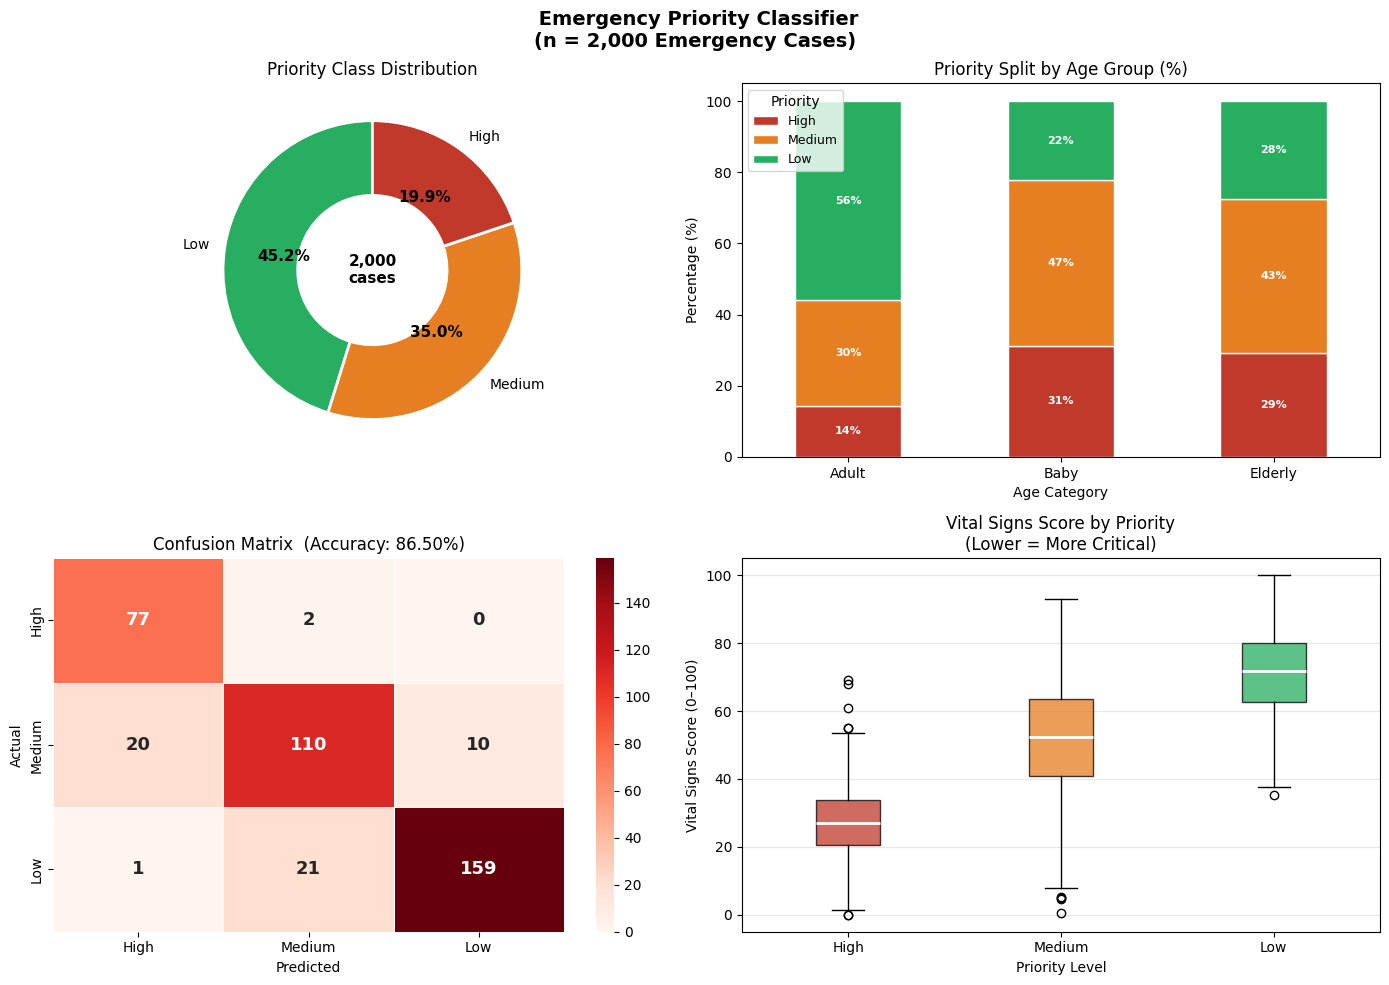

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    " Emergency Priority Classifier\n"
    "(n = 2,000 Emergency Cases)",
    fontsize=14, fontweight="bold"
)

priority_colors = {"High": "#c0392b", "Medium": "#e67e22", "Low": "#27ae60"}


priority_counts = emergency_df["Priority"].value_counts()
wedges, texts, autotexts = axes[0, 0].pie(
    priority_counts.values,
    labels=priority_counts.index,
    colors=[priority_colors[p] for p in priority_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
axes[0, 0].set_title("Priority Class Distribution")
axes[0, 0].text(0, 0, f"{n:,}\ncases",
                ha="center", va="center", fontsize=11, fontweight="bold")


cross = pd.crosstab(emergency_df["Age_Category"], emergency_df["Priority"])
cross = cross[["High", "Medium", "Low"]]   
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.plot(
    kind="bar", stacked=True, ax=axes[0, 1],
    color=[priority_colors["High"], priority_colors["Medium"], priority_colors["Low"]],
    edgecolor="white", rot=0
)
axes[0, 1].set_title("Priority Split by Age Group (%)")
axes[0, 1].set_xlabel("Age Category")
axes[0, 1].set_ylabel("Percentage (%)")
axes[0, 1].legend(title="Priority", fontsize=9)
for container in axes[0, 1].containers:
    labels_bar = [
        f"{v.get_height():.0f}%" if v.get_height() > 6 else ""
        for v in container
    ]
    axes[0, 1].bar_label(container, labels=labels_bar,
                         label_type="center", fontsize=8,
                         fontweight="bold", color="white")


cm = confusion_matrix(y_test, predictions, labels=["High", "Medium", "Low"])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",
    xticklabels=["High", "Medium", "Low"],
    yticklabels=["High", "Medium", "Low"],
    ax=axes[1, 0], linewidths=0.5,
    annot_kws={"size": 13, "weight": "bold"}
)
axes[1, 0].set_title(f"Confusion Matrix  (Accuracy: {accuracy*100:.2f}%)")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")


priority_order = ["High", "Medium", "Low"]
data_to_plot = [
    emergency_df[emergency_df["Priority"] == p]["Vital_Signs_Score"].values
    for p in priority_order
]
bp = axes[1, 1].boxplot(
    data_to_plot,
    tick_labels=priority_order,
    patch_artist=True
)
for patch, p in zip(bp["boxes"], priority_order):
    patch.set_facecolor(priority_colors[p])
    patch.set_alpha(0.75)
for median_line in bp["medians"]:
    median_line.set_color("white")
    median_line.set_linewidth(2)
axes[1, 1].set_title("Vital Signs Score by Priority\n(Lower = More Critical)")
axes[1, 1].set_xlabel("Priority Level")
axes[1, 1].set_ylabel("Vital Signs Score (0–100)")
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()

plt.show()


In [7]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

priority_colors = {"High": "#c0392b", "Medium": "#e67e22", "Low": "#27ae60"}

def plot_emergency_dashboard(age_categories):
    if not age_categories:
        print("Please select at least one age category.")
        return

    filtered = emergency_df[emergency_df["Age_Category"].isin(age_categories)].copy()

    if filtered.empty:
        print("No data for selected filters.")
        return

    n_filtered = len(filtered)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Emergency Priority Classifier\n(n = {n_filtered:,} Emergency Cases)",
        fontsize=14, fontweight="bold"
    )

    priority_counts = filtered["Priority"].value_counts()
    wedges, texts, autotexts = axes[0, 0].pie(
        priority_counts.values,
        labels=priority_counts.index,
        colors=[priority_colors[p] for p in priority_counts.index],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    axes[0, 0].set_title("Priority Class Distribution")
    axes[0, 0].text(0, 0, f"{n_filtered:,}\ncases",
                    ha="center", va="center", fontsize=11, fontweight="bold")

    cross = pd.crosstab(filtered["Age_Category"], filtered["Priority"])
    for col in ["High", "Medium", "Low"]:
        if col not in cross.columns:
            cross[col] = 0
    cross = cross[["High", "Medium", "Low"]]
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.plot(
        kind="bar", stacked=True, ax=axes[0, 1],
        color=[priority_colors["High"], priority_colors["Medium"], priority_colors["Low"]],
        edgecolor="white", rot=0
    )
    axes[0, 1].set_title("Priority Split by Age Group (%)")
    axes[0, 1].set_xlabel("Age Category")
    axes[0, 1].set_ylabel("Percentage (%)")
    axes[0, 1].legend(title="Priority", fontsize=9)
    for container in axes[0, 1].containers:
        labels_bar = [
            f"{v.get_height():.0f}%" if v.get_height() > 6 else ""
            for v in container
        ]
        axes[0, 1].bar_label(container, labels=labels_bar,
                             label_type="center", fontsize=8,
                             fontweight="bold", color="white")

    filtered_idx = filtered.index
    if hasattr(y_test, "index"):
        mask = y_test.index.isin(filtered_idx)
        y_test_f = y_test[mask]
        preds_f = predictions[mask] if hasattr(predictions, "__getitem__") else pd.Series(predictions, index=y_test.index)[mask]
    else:
        y_test_f = y_test
        preds_f = predictions

    acc_f = (y_test_f == preds_f).mean() if len(y_test_f) > 0 else 0
    cm = confusion_matrix(y_test_f, preds_f, labels=["High", "Medium", "Low"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Reds",
        xticklabels=["High", "Medium", "Low"],
        yticklabels=["High", "Medium", "Low"],
        ax=axes[1, 0], linewidths=0.5,
        annot_kws={"size": 13, "weight": "bold"}
    )
    axes[1, 0].set_title(f"Confusion Matrix  (Accuracy: {acc_f*100:.2f}%)")
    axes[1, 0].set_xlabel("Predicted")
    axes[1, 0].set_ylabel("Actual")

    priority_order = ["High", "Medium", "Low"]
    data_to_plot = [
        filtered[filtered["Priority"] == p]["Vital_Signs_Score"].values
        for p in priority_order
    ]
    bp = axes[1, 1].boxplot(
        data_to_plot,
        tick_labels=priority_order,
        patch_artist=True
    )
    for patch, p in zip(bp["boxes"], priority_order):
        patch.set_facecolor(priority_colors[p])
        patch.set_alpha(0.75)
    for median_line in bp["medians"]:
        median_line.set_color("white")
        median_line.set_linewidth(2)
    axes[1, 1].set_title("Vital Signs Score by Priority\n(Lower = More Critical)")
    axes[1, 1].set_xlabel("Priority Level")
    axes[1, 1].set_ylabel("Vital Signs Score (0–100)")
    axes[1, 1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

all_age_categories = sorted(emergency_df["Age_Category"].unique().tolist())

age_toggle = widgets.SelectMultiple(
    options=all_age_categories,
    value=all_age_categories,
    description="Age Group:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px", height=f"{28 * len(all_age_categories)}px")
)

out = widgets.interactive_output(plot_emergency_dashboard, {"age_categories": age_toggle})
display(widgets.HBox([age_toggle, widgets.Label("← Hold Ctrl/Cmd to multi-select")]), out)

Output()

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display


# ── THEME ─────────────────────────────────────────────────────
BG       = "#0d1117"
PANEL    = "#161b22"
GRID_C   = "#21262d"
TEXT     = "#e6edf3"
DIM      = "#8b949e"
HIGH     = "#ff4d4d"
MED      = "#ffa500"
LOW      = "#00c853"
ACCENT   = "#58a6ff"

PRIORITY_COLORS = {"High": HIGH, "Medium": MED, "Low": LOW}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   GRID_C,
    "axes.labelcolor":  DIM,
    "axes.titlecolor":  TEXT,
    "axes.grid":        True,
    "grid.color":       GRID_C,
    "grid.linewidth":   0.6,
    "xtick.color":      DIM,
    "ytick.color":      DIM,
    "text.color":       TEXT,
    "font.family":      "monospace",
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID_C,
})

# ── DASHBOARD ─────────────────────────────────────────────────
def plot_priority_dashboard(priority_filter):
    if priority_filter == "All":
        data = emergency_df.copy()
    else:
        data = emergency_df[emergency_df["Priority"] == priority_filter].copy()

    if data.empty:
        print("No data for selected filter.")
        return

    n = len(data)

    fig = plt.figure(figsize=(18, 13), facecolor=BG)
    filter_label = priority_filter if priority_filter != "All" else "All Priorities"
    fig.suptitle(
        f"SafeSphere  ·  Emergency Priority Classifier  ·  {filter_label}  ·  n = {n:,} cases",
        fontsize=14, fontweight="bold", color=TEXT, y=0.97
    )

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.45, wspace=0.38,
        top=0.91, bottom=0.07,
        left=0.06, right=0.97
    )

    # ── 1. VITAL SIGNS DISTRIBUTION BAR (full top row) ────────────
    ax1 = fig.add_subplot(gs[0, :])

    bins      = np.arange(0, 105, 5)
    p_order   = ["High", "Medium", "Low"]
    bottoms   = np.zeros(len(bins) - 1)

    for p in p_order:
        sub = data[data["Priority"] == p]["Vital_Signs_Score"]
        if sub.empty:
            continue
        counts, _ = np.histogram(sub, bins=bins)
        bars = ax1.bar(
            bins[:-1] + 2.5, counts,
            width=4.2, bottom=bottoms,
            color=PRIORITY_COLORS[p], alpha=0.88,
            label=p, zorder=3
        )
        bottoms += counts

    ax1.set_title(
        f"Vital Signs Score Distribution by Priority  ·  (Lower score = More Critical)",
        fontsize=11, pad=10
    )
    ax1.set_xlabel("Vital Signs Score (0–100)", fontsize=9)
    ax1.set_ylabel("Number of Cases", fontsize=9)
    ax1.set_xlim(-2, 102)
    patches = [mpatches.Patch(color=PRIORITY_COLORS[p], label=p) for p in p_order]
    ax1.legend(handles=patches, fontsize=9, loc="upper right",
               framealpha=0.3, ncol=3)

    # critical zone shading
    ax1.axvspan(0, 30, alpha=0.06, color=HIGH, zorder=0)
    ax1.text(15, ax1.get_ylim()[1] * 0.92, "Critical\nZone",
             ha="center", fontsize=7.5, color=HIGH, alpha=0.7)

    # ── 2. 3D BAR: VITAL SCORE BUCKETS PER PRIORITY ──────────────
    ax2 = fig.add_subplot(gs[1, 0], projection="3d")
    ax2.set_facecolor(PANEL)

    buckets      = ["0–20", "21–40", "41–60", "61–80", "81–100"]
    bucket_edges = [0, 20, 40, 60, 80, 100]
    priorities   = ["High", "Medium", "Low"]

    xpos_all, ypos_all, zpos_all = [], [], []
    dx_all, dy_all, dz_all, col_all = [], [], [], []

    for yi, p in enumerate(priorities):
        sub = data[data["Priority"] == p]["Vital_Signs_Score"]
        for xi, (lo, hi) in enumerate(zip(bucket_edges, bucket_edges[1:])):
            cnt = ((sub >= lo) & (sub < hi)).sum()
            xpos_all.append(xi * 1.2)
            ypos_all.append(yi * 1.4)
            zpos_all.append(0)
            dx_all.append(0.9)
            dy_all.append(0.9)
            dz_all.append(cnt)
            col_all.append(PRIORITY_COLORS[p])

    ax2.bar3d(xpos_all, ypos_all, zpos_all,
              dx_all, dy_all, dz_all,
              color=col_all, alpha=0.82, shade=True)

    ax2.set_title("3D: Cases per\nScore Bucket & Priority", fontsize=9, pad=6)
    ax2.set_xticks([i * 1.2 + 0.45 for i in range(5)])
    ax2.set_xticklabels(buckets, fontsize=6)
    ax2.set_yticks([i * 1.4 + 0.45 for i in range(3)])
    ax2.set_yticklabels(priorities, fontsize=6.5)
    ax2.set_zlabel("Cases", fontsize=7, labelpad=2)
    ax2.tick_params(colors=DIM, labelsize=6)
    ax2.xaxis.pane.fill = False
    ax2.yaxis.pane.fill = False
    ax2.zaxis.pane.fill = False
    ax2.xaxis.pane.set_edgecolor(GRID_C)
    ax2.yaxis.pane.set_edgecolor(GRID_C)
    ax2.zaxis.pane.set_edgecolor(GRID_C)
    ax2.view_init(elev=24, azim=-50)

    # ── 3. DONUT: PRIORITY SPLIT ──────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    p_counts = data["Priority"].value_counts()
    labels   = [k for k in ["High", "Medium", "Low"] if k in p_counts]
    vals     = [p_counts[k] for k in labels]
    cols     = [PRIORITY_COLORS[k] for k in labels]

    wedges, _, autos = ax3.pie(
        vals, colors=cols, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops={"width": 0.52, "edgecolor": BG, "linewidth": 2.5}
    )
    for at in autos:
        at.set_fontsize(9)
        at.set_color(TEXT)
        at.set_fontweight("bold")

    ax3.text(0, 0, f"{n:,}\ncases", ha="center", va="center",
             fontsize=11, fontweight="bold", color=TEXT)
    ax3.set_title(f"Priority Split\n({filter_label})", fontsize=9, pad=8)
    ax3.legend(
        handles=[mpatches.Patch(color=PRIORITY_COLORS[l],
                 label=f"{l}  ({p_counts.get(l, 0):,})") for l in ["High", "Medium", "Low"]],
        fontsize=7.5, loc="lower center", ncol=3,
        bbox_to_anchor=(0.5, -0.12), framealpha=0.2
    )

    # ── 4. BOXPLOT: VITAL SIGNS PER AGE CATEGORY ─────────────────
    ax4 = fig.add_subplot(gs[1, 2])

    age_order = sorted(data["Age_Category"].unique())
    box_data  = [data[data["Age_Category"] == a]["Vital_Signs_Score"].dropna().values
                 for a in age_order]

    bp = ax4.boxplot(
        box_data, tick_labels=age_order,
        patch_artist=True, widths=0.55,
        medianprops={"color": TEXT, "linewidth": 2},
        whiskerprops={"color": DIM,  "linewidth": 1.2},
        capprops={"color": DIM,    "linewidth": 1.2},
        flierprops={"marker": "o", "color": ACCENT, "alpha": 0.3,
                    "markersize": 3, "markeredgewidth": 0}
    )

    box_fill_colors = [HIGH, MED, LOW, ACCENT, "#b44fff"]
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(box_fill_colors[i % len(box_fill_colors)])
        patch.set_alpha(0.65)

    ax4.set_title("Vital Signs by Age Category", fontsize=9, pad=8)
    ax4.set_xlabel("Age Category", fontsize=8)
    ax4.set_ylabel("Vital Signs Score (0–100)", fontsize=8)
    ax4.set_ylim(0, 105)
    ax4.tick_params(axis="x", labelsize=7.5)

    plt.show()


# ── WIDGETS ───────────────────────────────────────────────────
options = ["All", "High", "Medium", "Low"]

toggle = widgets.ToggleButtons(
    options=options,
    value="All",
    description="",
    button_style="",
    tooltips=["Show all cases", "High priority only", "Medium priority only", "Low priority only"],
    style={
        "button_width":       "110px",
        "font_weight":        "bold",
        "description_width":  "0px",
    },
    layout=widgets.Layout(margin="0")
)

header = widgets.HTML("""
<div style='
  background:#161b22;
  border:1px solid #21262d;
  border-radius:10px;
  padding:12px 20px;
  margin-bottom:8px;
  font-family:monospace;
'>
  <span style='color:#58a6ff;font-size:13px;letter-spacing:2px'>
    🚨 SAFESPHERE  ·  EMERGENCY PRIORITY CLASSIFIER
  </span><br>
  <span style='color:#8b949e;font-size:11px'>
    Click a priority level to filter all 4 graphs simultaneously
  </span>
</div>
""")

filter_label = widgets.HTML("<span style='font-family:monospace;color:#8b949e;font-size:11px'>Priority Filter →</span>")

controls = widgets.HBox(
    [filter_label, toggle],
    layout=widgets.Layout(
        align_items="center", gap="12px",
        padding="10px 16px",
        border="1px solid #21262d",
        border_radius="8px",
        margin="0 0 14px 0"
    )
)

out = widgets.interactive_output(
    plot_priority_dashboard,
    {"priority_filter": toggle}
)

display(header, controls, out)


HTML(value="\n<div style='\n  background:#161b22;\n  border:1px solid #21262d;\n  border-radius:10px;\n  paddi…

Output()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D



BG     = "#0d1117"
PANEL  = "#161b22"
GRID_C = "#21262d"
TEXT   = "#e6edf3"
DIM    = "#8b949e"
HIGH   = "#ff4d4d"
MED    = "#ffa500"
LOW    = "#00c853"
ACCENT = "#58a6ff"

PRIORITY_COLORS = {"High": HIGH, "Medium": MED, "Low": LOW}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   GRID_C,
    "axes.labelcolor":  DIM,
    "axes.titlecolor":  TEXT,
    "axes.grid":        True,
    "grid.color":       GRID_C,
    "grid.linewidth":   0.6,
    "xtick.color":      DIM,
    "ytick.color":      DIM,
    "text.color":       TEXT,
    "font.family":      "monospace",
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID_C,
})


def plot_priority_dashboard(age_filter):
    if age_filter == "All":
        data = emergency_df.copy()
    else:
        data = emergency_df[emergency_df["Age_Category"] == age_filter].copy()

    if data.empty:
        print("No data for selected age group.")
        return

    n        = len(data)
    p_counts = data["Priority"].value_counts()
    high_n   = p_counts.get("High",   0)
    med_n    = p_counts.get("Medium", 0)
    low_n    = p_counts.get("Low",    0)

    fig = plt.figure(figsize=(18, 13), facecolor=BG)
    fig.suptitle(
        f"SafeSphere  ·  Emergency Priority Classifier  ·  Age: {age_filter}"
        f"  ·  n = {n:,}        High: {high_n}  |  Medium: {med_n}  |  Low: {low_n}",
        fontsize=13, fontweight="bold", color=TEXT, y=0.97
    )

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.45, wspace=0.38,
        top=0.91, bottom=0.07,
        left=0.06, right=0.97
    )

    ax1 = fig.add_subplot(gs[0, :])

    bins    = np.arange(0, 105, 5)
    bottoms = np.zeros(len(bins) - 1)

    for p in ["High", "Medium", "Low"]:
        sub = data[data["Priority"] == p]["Vital_Signs_Score"]
        if sub.empty:
            continue
        counts, _ = np.histogram(sub, bins=bins)
        ax1.bar(
            bins[:-1] + 2.5, counts,
            width=4.2, bottom=bottoms,
            color=PRIORITY_COLORS[p], alpha=0.88,
            label=p, zorder=3
        )
        bottoms += counts

    ax1.axvspan(0, 30, alpha=0.07, color=HIGH, zorder=0)
    cur_ymax = ax1.get_ylim()[1]
    ymax = cur_ymax if cur_ymax > 0 else 10
    ax1.text(15, ymax * 0.88, "Critical\nZone",
             ha="center", fontsize=8, color=HIGH, alpha=0.8)
    ax1.set_title(
        f"Vital Signs Score Distribution  —  Age: {age_filter}"
        "        (Lower score = More Critical)",
        fontsize=11, pad=10
    )
    ax1.set_xlabel("Vital Signs Score (0–100)", fontsize=9)
    ax1.set_ylabel("Number of Cases", fontsize=9)
    ax1.set_xlim(-2, 102)
    ax1.legend(
        handles=[mpatches.Patch(color=PRIORITY_COLORS[p], label=p)
                 for p in ["High", "Medium", "Low"]],
        fontsize=9, loc="upper right", framealpha=0.3, ncol=3
    )

    ax2 = fig.add_subplot(gs[1, 0], projection="3d")
    ax2.set_facecolor(PANEL)

    buckets      = ["0–20", "21–40", "41–60", "61–80", "81–100"]
    bucket_edges = [0, 20, 40, 60, 80, 100]
    priorities   = ["High", "Medium", "Low"]

    xpos_all, ypos_all, zpos_all = [], [], []
    dx_all, dy_all, dz_all, col_all = [], [], [], []

    for yi, p in enumerate(priorities):
        sub = data[data["Priority"] == p]["Vital_Signs_Score"]
        for xi, (lo, hi) in enumerate(zip(bucket_edges, bucket_edges[1:])):
            cnt = int(((sub >= lo) & (sub < hi)).sum())
            xpos_all.append(xi * 1.2)
            ypos_all.append(yi * 1.4)
            zpos_all.append(0)
            dx_all.append(0.9)
            dy_all.append(0.9)
            dz_all.append(max(cnt, 0))
            col_all.append(PRIORITY_COLORS[p])

    ax2.bar3d(xpos_all, ypos_all, zpos_all,
              dx_all, dy_all, dz_all,
              color=col_all, alpha=0.82, shade=True)

    ax2.set_title(f"3D: Cases per Score\nBucket & Priority  [{age_filter}]",
                  fontsize=9, pad=6)
    ax2.set_xticks([i * 1.2 + 0.45 for i in range(5)])
    ax2.set_xticklabels(buckets, fontsize=6)
    ax2.set_yticks([i * 1.4 + 0.45 for i in range(3)])
    ax2.set_yticklabels(priorities, fontsize=6.5)
    ax2.set_zlabel("Cases", fontsize=7, labelpad=2)
    ax2.tick_params(colors=DIM, labelsize=6)
    ax2.xaxis.pane.fill = False
    ax2.yaxis.pane.fill = False
    ax2.zaxis.pane.fill = False
    ax2.xaxis.pane.set_edgecolor(GRID_C)
    ax2.yaxis.pane.set_edgecolor(GRID_C)
    ax2.zaxis.pane.set_edgecolor(GRID_C)
    ax2.view_init(elev=24, azim=-50)

    ax3 = fig.add_subplot(gs[1, 1])

    labels = [k for k in ["High", "Medium", "Low"]
              if k in p_counts and p_counts[k] > 0]
    vals   = [p_counts[k] for k in labels]
    cols   = [PRIORITY_COLORS[k] for k in labels]

    wedges, _, autos = ax3.pie(
        vals, colors=cols, autopct="%1.1f%%",
        startangle=90, pctdistance=0.78,
        wedgeprops={"width": 0.52, "edgecolor": BG, "linewidth": 2.5}
    )
    for at in autos:
        at.set_fontsize(9)
        at.set_color(TEXT)
        at.set_fontweight("bold")

    ax3.text(0, 0, f"{n:,}\ncases", ha="center", va="center",
             fontsize=11, fontweight="bold", color=TEXT)
    ax3.set_title(f"Priority Split\nAge: {age_filter}", fontsize=9, pad=8)
    ax3.legend(
        handles=[mpatches.Patch(color=PRIORITY_COLORS[l],
                 label=f"{l}  ({p_counts.get(l, 0):,})")
                 for l in ["High", "Medium", "Low"]],
        fontsize=7.5, loc="lower center", ncol=3,
        bbox_to_anchor=(0.5, -0.12), framealpha=0.2
    )

    ax4 = fig.add_subplot(gs[1, 2])

    all_ages = sorted(emergency_df["Age_Category"].unique())
    x        = np.arange(len(all_ages))
    width    = 0.25

    for i, p in enumerate(["High", "Medium", "Low"]):
        counts = [
            len(emergency_df[(emergency_df["Age_Category"] == a) &
                             (emergency_df["Priority"] == p)])
            for a in all_ages
        ]
        bars = ax4.bar(
            x + i * width, counts, width,
            color=PRIORITY_COLORS[p], alpha=0.85,
            label=p, zorder=3
        )

        if age_filter != "All" and age_filter in all_ages:
            idx = all_ages.index(age_filter)
            bars[idx].set_edgecolor(TEXT)
            bars[idx].set_linewidth(2.2)

   
    if age_filter != "All" and age_filter in all_ages:
        idx = all_ages.index(age_filter)
        ax4.axvspan(idx - 0.15, idx + 0.85, alpha=0.07,
                    color=ACCENT, zorder=0)

    ax4.set_title("Priority Count Across All Age Groups\n(selected group highlighted)",
                  fontsize=9, pad=8)
    ax4.set_xlabel("Age Category", fontsize=8)
    ax4.set_ylabel("Number of Cases", fontsize=8)
    ax4.set_xticks(x + width)
    ax4.set_xticklabels(all_ages, fontsize=8, rotation=15)
    ax4.legend(fontsize=8, framealpha=0.3)

    plt.show()



all_ages = ["All"] + sorted(emergency_df["Age_Category"].unique().tolist())

toggle = widgets.ToggleButtons(
    options=all_ages,
    value="All",
    description="",
    button_style="",
    style={"button_width": "100px", "font_weight": "bold",
           "description_width": "0px"},
    layout=widgets.Layout(margin="0")
)

header = widgets.HTML("""
<div style='
  background:#161b22;
  border:1px solid #21262d;
  border-radius:10px;
  padding:12px 20px;
  margin-bottom:8px;
  font-family:monospace;
'>
  <span style='color:#58a6ff;font-size:13px;letter-spacing:2px'>
    🚨 SAFESPHERE  ·  EMERGENCY PRIORITY CLASSIFIER
  </span><br>
  <span style='color:#8b949e;font-size:11px'>
    Click an age group → all 4 graphs update · selected group highlighted in bottom-right chart
  </span>
</div>
""")

controls = widgets.HBox(
    [widgets.HTML("<span style='font-family:monospace;color:#8b949e;"
                  "font-size:11px;white-space:nowrap'>Age Group →</span>"),
     toggle],
    layout=widgets.Layout(
        align_items="center", gap="12px",
        padding="10px 16px",
        border="1px solid #21262d",
        border_radius="8px",
        margin="0 0 14px 0"
    )
)

out = widgets.interactive_output(
    plot_priority_dashboard,
    {"age_filter": toggle}
)

display(header, controls, out)


HTML(value="\n<div style='\n  background:#161b22;\n  border:1px solid #21262d;\n  border-radius:10px;\n  paddi…

Output()